Dataset created: 150 samples, 14 channels
Number of users: 5
Dataset shape: (150, 14, 256)
Number of samples: 150
Number of channels: 14
Time points per channel: 256
Number of users: 5
Users: [0 1 2 3 4]


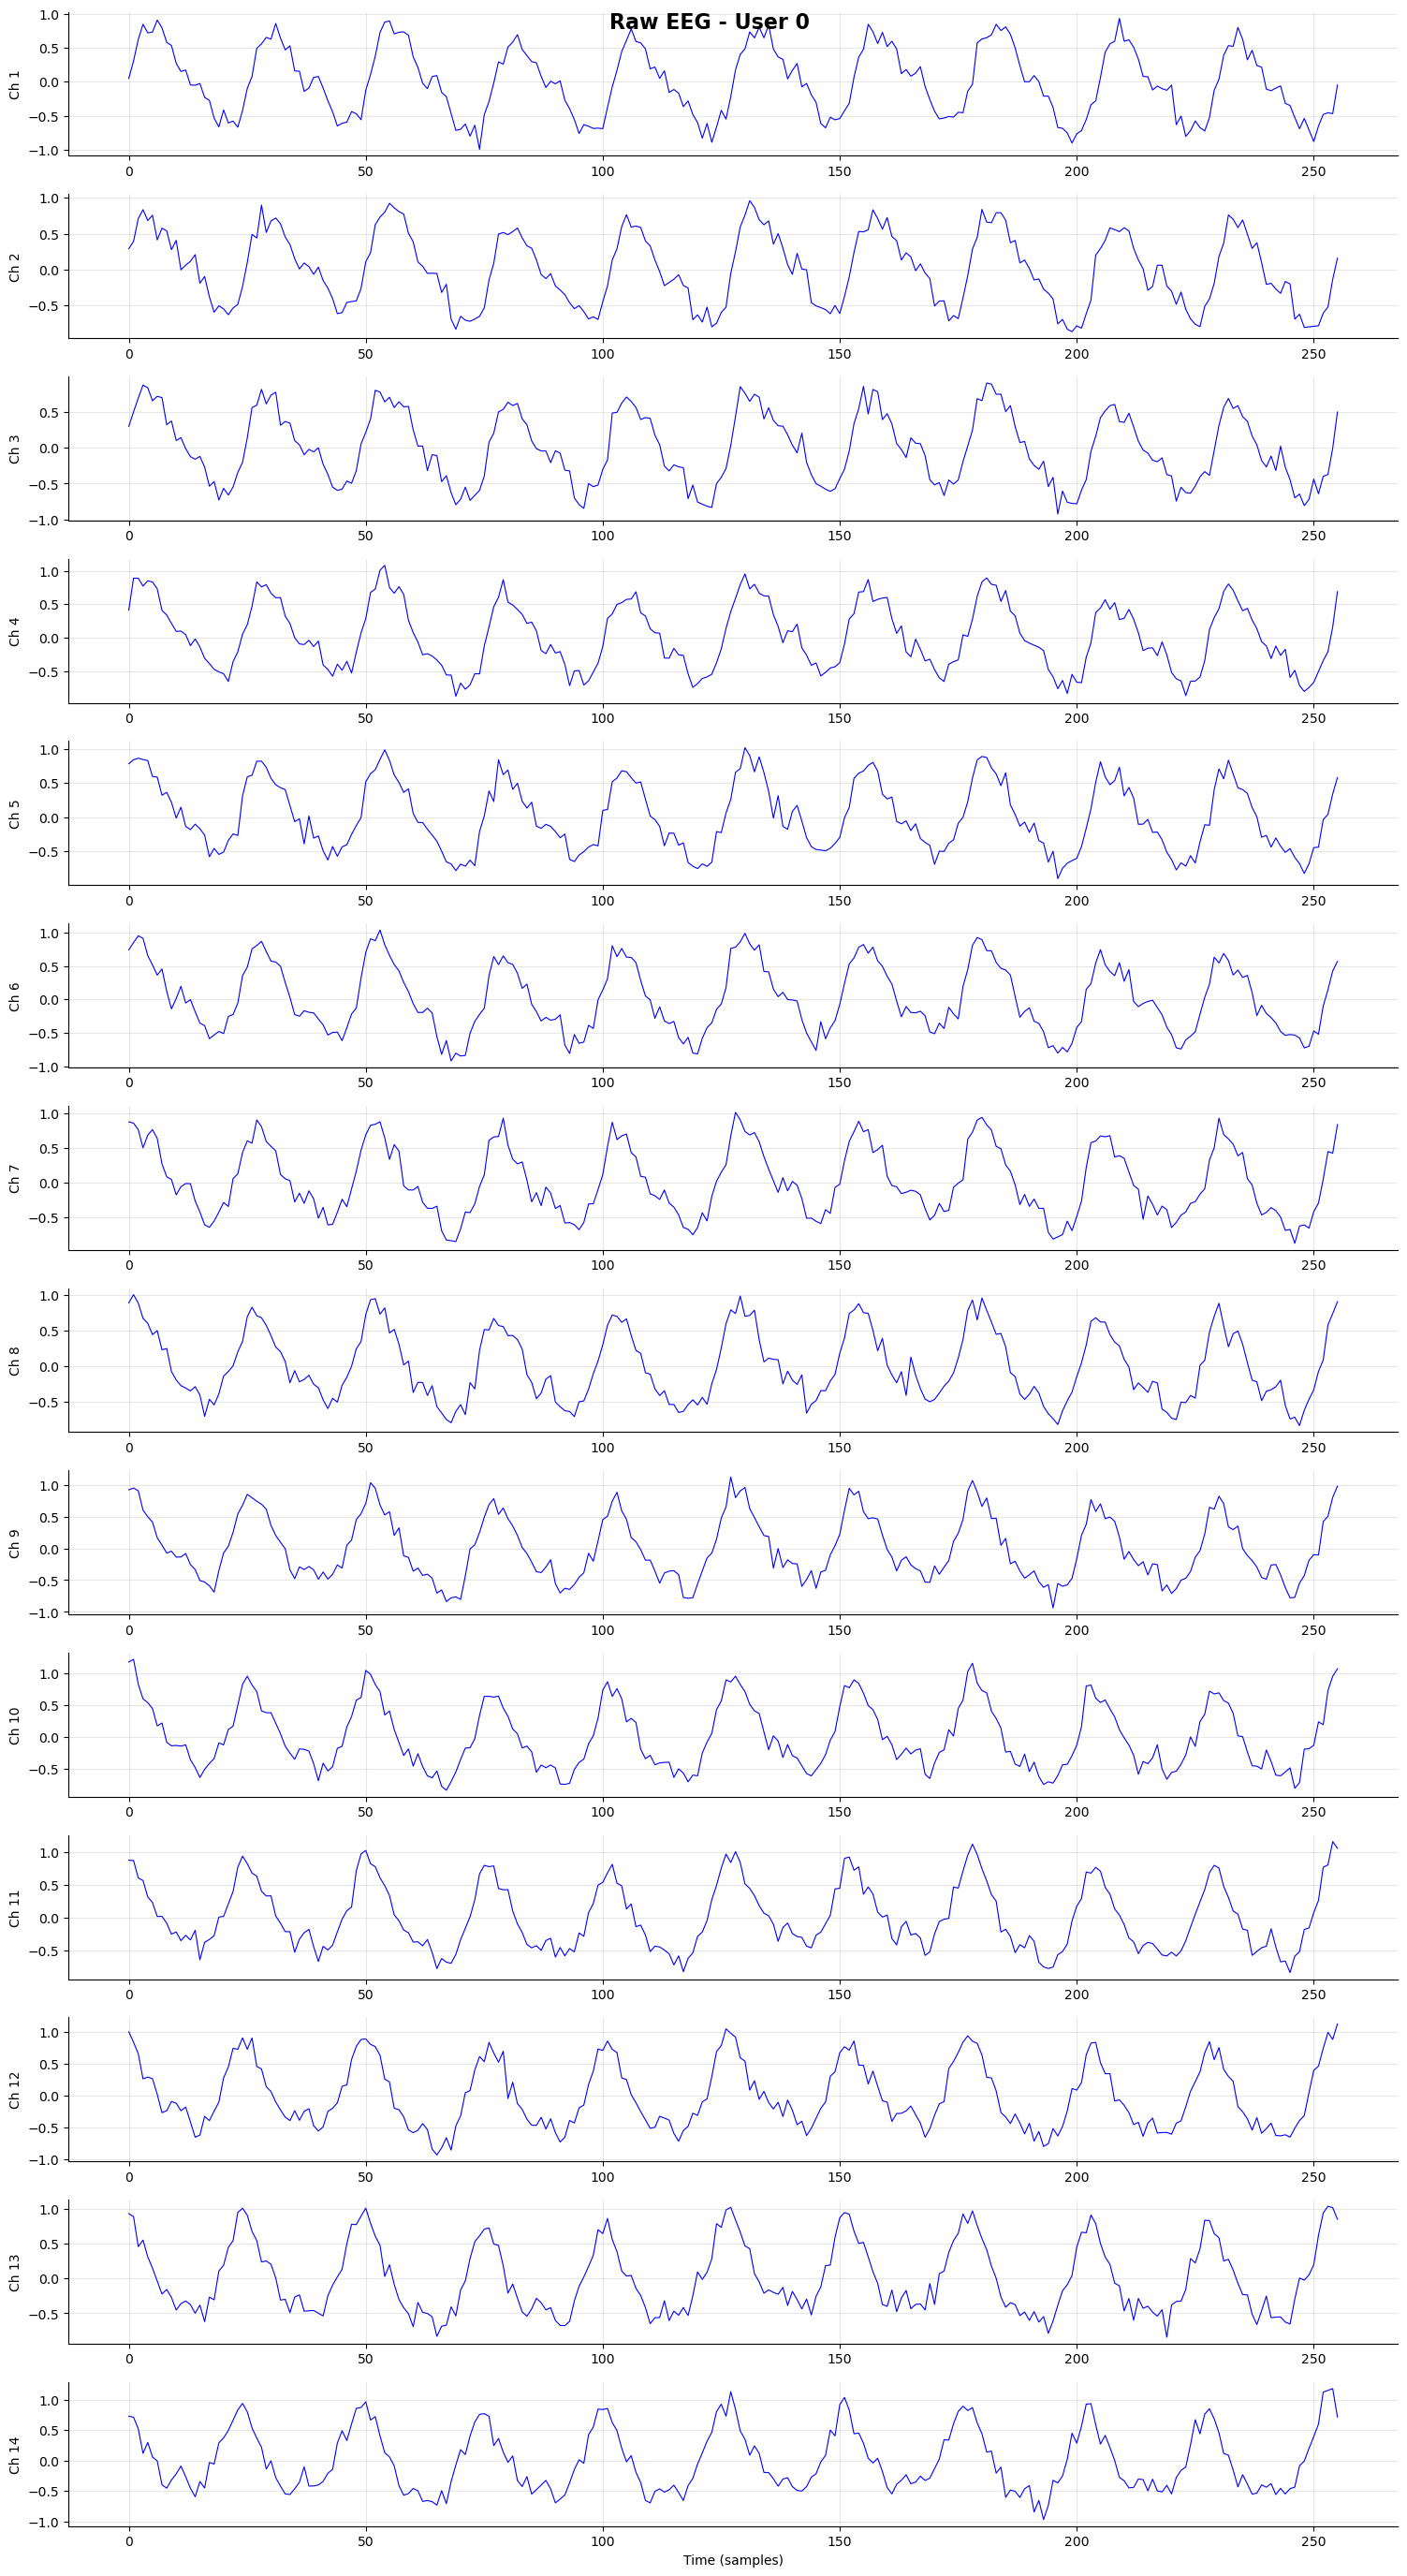

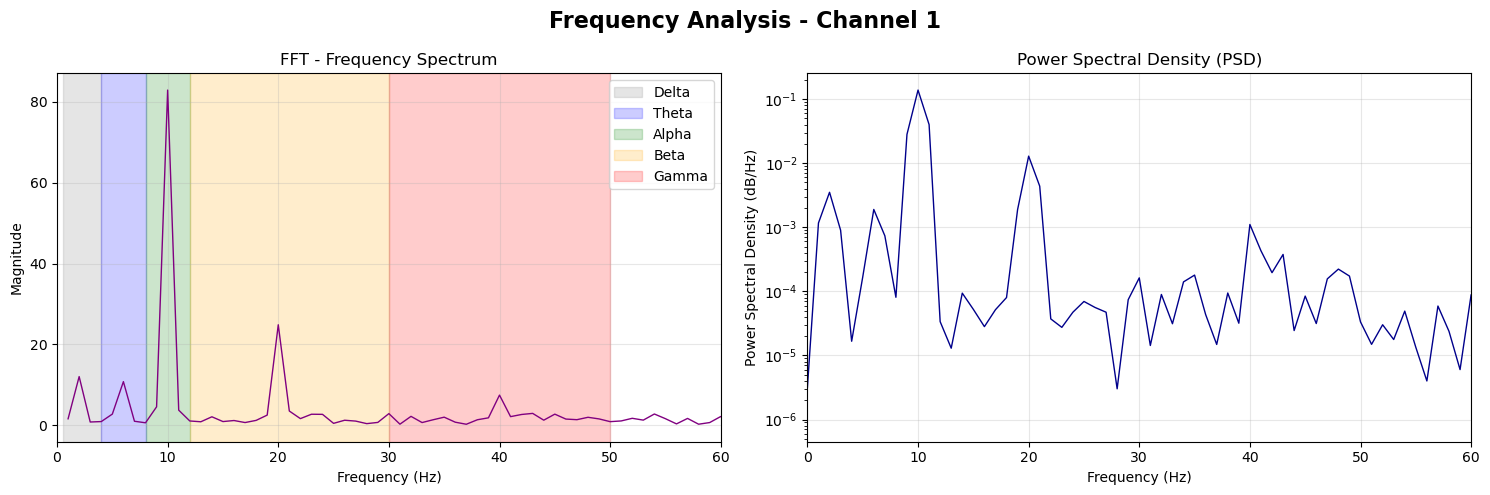

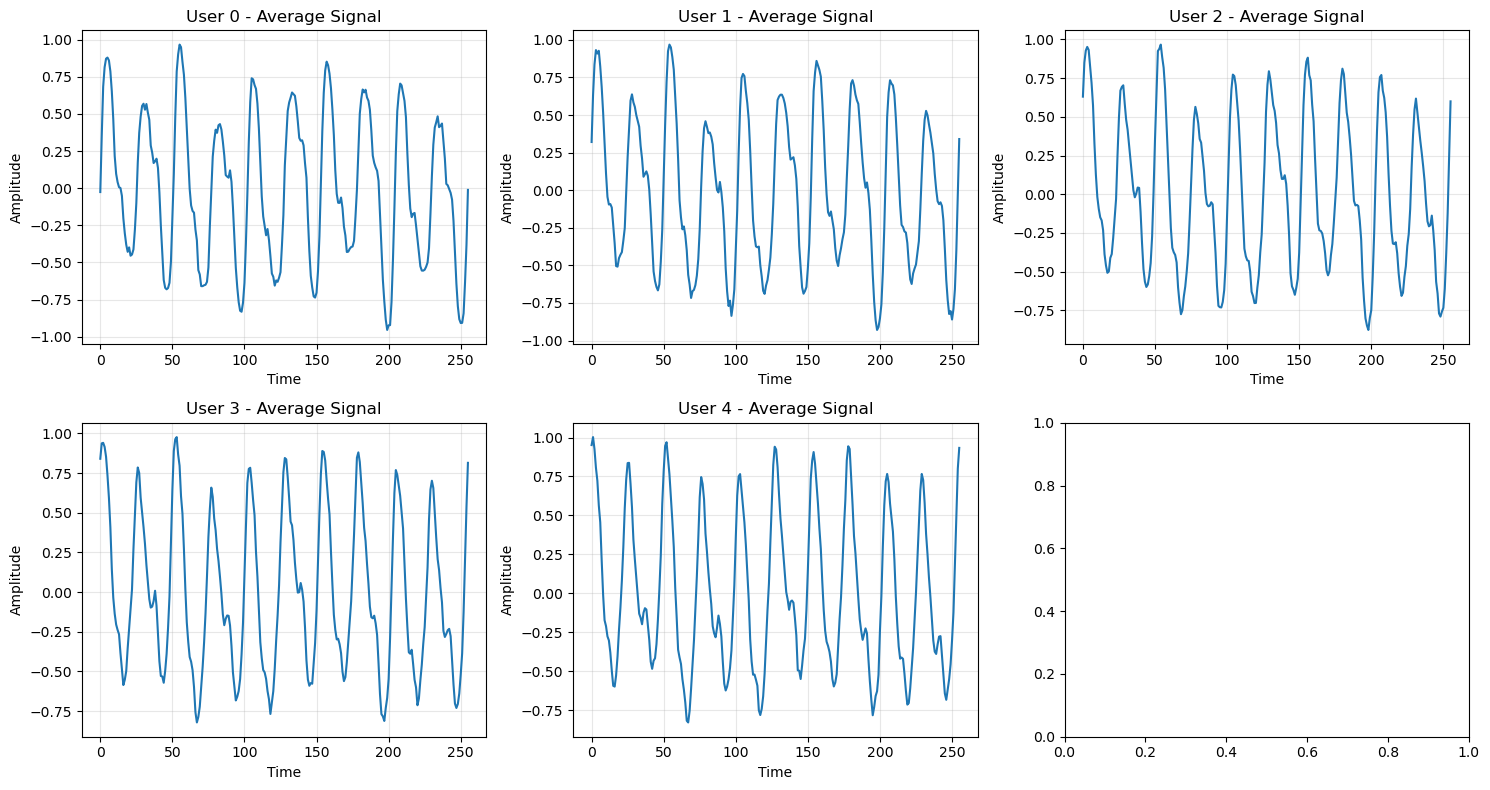


Statistical Summary per User:

User 0:
  Mean: 0.0028
  Std: 0.5108
  Min: -1.4019
  Max: 1.3694

User 1:
  Mean: 0.0030
  Std: 0.5119
  Min: -1.3089
  Max: 1.4526

User 2:
  Mean: 0.0029
  Std: 0.5113
  Min: -1.2739
  Max: 1.4636

User 3:
  Mean: 0.0029
  Std: 0.5112
  Min: -1.1827
  Max: 1.5426

User 4:
  Mean: 0.0017
  Std: 0.5103
  Min: -1.1687
  Max: 1.4530


In [1]:
# %% [markdown]
# # Brainwave Authentication System - Data Exploration
# ## EEG Signal Analysis and Visualization

# %%
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('..')

from src.data_loader import EEGDataLoader
from src.visualization import EEGVisualizer

# %%
# Load sample dataset
data_loader = EEGDataLoader()
X, y = data_loader.load_sample_dataset(n_users=5, samples_per_user=30)
visualizer = EEGVisualizer()

# %%
# Display dataset info
print(f"Dataset shape: {X.shape}")
print(f"Number of samples: {X.shape[0]}")
print(f"Number of channels: {X.shape[1]}")
print(f"Time points per channel: {X.shape[2]}")
print(f"Number of users: {len(np.unique(y))}")
print(f"Users: {np.unique(y)}")

# %%
# Plot raw EEG signals for a sample
sample_idx = 0
visualizer.plot_raw_eeg(X[sample_idx], title=f"Raw EEG - User {y[sample_idx]}")

# %%
# Plot frequency spectrum
visualizer.plot_frequency_spectrum(X[sample_idx], sampling_rate=256, channel_idx=0)

# %%
# Compare different users
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, user in enumerate(np.unique(y)[:6]):  # First 6 users
    user_samples = X[y == user]
    avg_signal = np.mean(user_samples, axis=0)[0]  # Average of channel 0
    
    axes[i].plot(avg_signal)
    axes[i].set_title(f'User {user} - Average Signal')
    axes[i].set_xlabel('Time')
    axes[i].set_ylabel('Amplitude')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# %%
# Statistical summary
print("\nStatistical Summary per User:")
for user in np.unique(y):
    user_data = X[y == user]
    print(f"\nUser {user}:")
    print(f"  Mean: {np.mean(user_data):.4f}")
    print(f"  Std: {np.std(user_data):.4f}")
    print(f"  Min: {np.min(user_data):.4f}")
    print(f"  Max: {np.max(user_data):.4f}")